Average PM2.5 Concentration:
          city   pm25
0      Chicago  10.60
1      Houston  14.10
2  Los Angeles  15.70
3     New York  11.35
Monthly Air Quality Index (AQI):
          city  year  month   aqi_pm25
0      Chicago  2022      1  44.166667
1      Houston  2022      1  55.206009
2  Los Angeles  2022      1  58.570815
3     New York  2022      1  47.170601


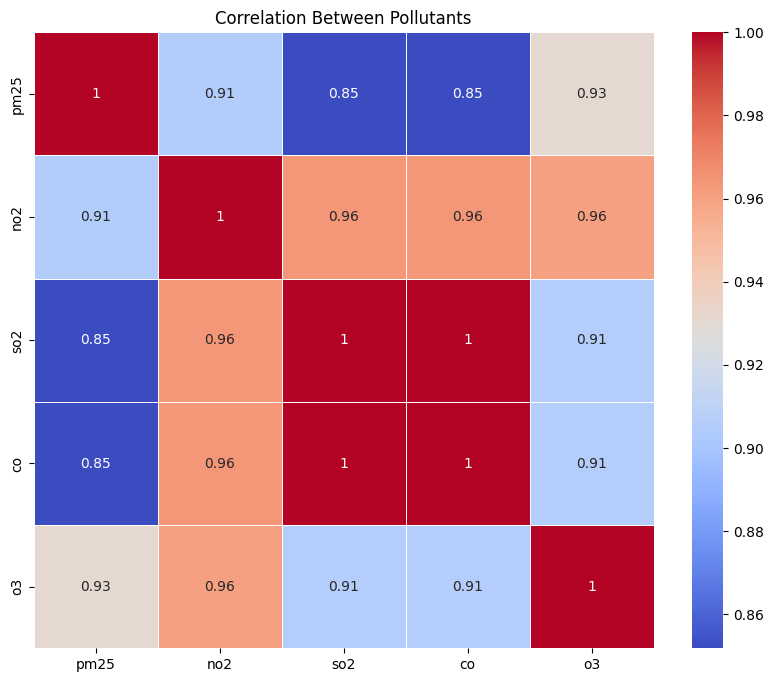

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Read the CSV file
air_quality_data = pd.read_csv('air_quality_data.csv')
# Convert date column to datetime
air_quality_data['date'] = pd.to_datetime(air_quality_data['date'])
# Extract month and year
air_quality_data['month'] = air_quality_data['date'].dt.month
air_quality_data['year'] = air_quality_data['date'].dt.year
# Calculate the average PM2.5 concentration for each city
avg_pm25 = air_quality_data.groupby('city')['pm25'].mean().reset_index()
print("Average PM2.5 Concentration:")
print(avg_pm25)
# Function to calculate AQI based on PM2.5 concentration
def calculate_aqi_pm25(pm25):
    if pm25 <= 12:
        aqi = (50 - 0) / (12 - 0) * (pm25 - 0) + 0
    elif pm25 <= 35.4:
        aqi = (100 - 51) / (35.4 - 12.1) * (pm25 - 12.1) + 51
    else:
        aqi = 101
    return aqi
# Calculate AQI for each record
air_quality_data['aqi_pm25'] = air_quality_data['pm25'].apply(calculate_aqi_pm25)
# Calculate the monthly AQI for each city
monthly_aqi = air_quality_data.groupby(['city', 'year', 'month'])['aqi_pm25'].mean().reset_index()
print("Monthly Air Quality Index (AQI):")
print(monthly_aqi)
# Calculate the correlation between pollutants
pollutant_corr = air_quality_data[['pm25', 'no2', 'so2', 'co', 'o3']].corr()
# Visualize the correlation using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pollutant_corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Pollutants")
# Display the heatmap
plt.show()